# Projeto 2 — Referência de Teto: Transfer Learning com ResNet-18

**Este notebook NÃO é a entrega do Projeto 2.** A entrega é a CNN projetada do
zero em `projeto2.ipynb`, conforme o enunciado exige (*"Implementar a
arquitetura escolhida em PyTorch com design justificado: número de filtros,
profundidade, stride/padding devem ter razões técnicas conectadas ao problema"*).

## Para que serve

O experimento responde a **uma pergunta específica** que a CNN do zero deixou
aberta:

> A AUROC de teste travada em ~0,94 é limitação da **arquitetura** ou do
> **dataset**?

O diagnóstico principal do Projeto 2 identificou um gap persistente entre
validação (AUROC ~0,998) e teste (AUROC ~0,940), atribuído a deslocamento de
distribuição entre as pastas `train/` e `test/` oficiais. Se um modelo
pré-treinado em 1,2 milhão de imagens do ImageNet **também** mantiver esse gap,
a atribuição está confirmada. Se ele fechar o gap, a causa era capacidade do
modelo e o diagnóstico precisa ser revisto.

## Alinhamento metodológico

Transfer Learning com ResNet-18 é a abordagem apresentada em duas aulas do
curso:

- **Aula 5, parte 3**, seção *"11. Bônus: Transfer Learning com ResNet18"*
- **Aula 7 (prática extra, EuroSAT)**, onde a ResNet-18 pré-treinada é o
  modelo principal, com `AdamW`, `CosineAnnealingLR` e `StratifiedKFold`

Este notebook segue o mesmo pipeline de dados de `projeto2.ipynb` — split
agrupado por paciente, mesmas transformações, mesma seed — para que a única
variável seja a arquitetura.

In [1]:
# ---------------------------------------------------------------
# 1. Ambiente
# ---------------------------------------------------------------
import os
import re
import json
from collections import Counter
from datetime import datetime
from pathlib import Path

import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, average_precision_score)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")
print(f"torch {torch.__version__}")


Dispositivo em uso: mps
torch 2.13.0


In [2]:
# ---------------------------------------------------------------
# 2. Dados — pipeline IDENTICO ao de projeto2.ipynb
#
# Mesmo split agrupado por paciente, mesmas transformacoes, mesma seed.
# Unica variavel do experimento: a arquitetura.
# ---------------------------------------------------------------
IMG_SIZE = 128
BATCH_SIZE = 32
VAL_FRACTION = 1 / 7

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
dataset_path = os.path.join(path, 'chest_xray')
full_train = ImageFolder(root=os.path.join(dataset_path, 'train'))
test_base  = ImageFolder(root=os.path.join(dataset_path, 'test'))
class_names = full_train.classes

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# split agrupado por paciente (personNNN no name do arquivo)
all_labels = np.array(full_train.targets)
PATIENT_ID_PATTERN = re.compile(r"person(\d+)_")
patient_groups = np.array([
    f"p{m.group(1)}" if (m := PATIENT_ID_PATTERN.match(os.path.basename(caminho)))
    else f"arquivo{i}"
    for i, (caminho, _) in enumerate(full_train.samples)
])
sgkf = StratifiedGroupKFold(n_splits=int(1 / VAL_FRACTION), shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(np.zeros(len(all_labels)), all_labels, patient_groups))
assert not (set(patient_groups[train_idx]) & set(patient_groups[val_idx])), "vazamento de grupo!"


class ApplyTransform(Dataset):
    def __init__(self, subset, transform=None):
        self.subset, self.transform = subset, transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        return (self.transform(x) if self.transform else x), y
    def __len__(self):
        return len(self.subset)


train_loader = DataLoader(ApplyTransform(Subset(ImageFolder(os.path.join(dataset_path,'train'),
                          transform=None), train_idx), train_transform),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(ApplyTransform(Subset(ImageFolder(os.path.join(dataset_path,'train'),
                          transform=None), val_idx), eval_transform),
                          batch_size=64, shuffle=False)
test_loader  = DataLoader(ApplyTransform(test_base, eval_transform),
                          batch_size=64, shuffle=False)

cont = Counter(all_labels[train_idx])
n_train = len(train_idx)
class_weights = torch.tensor([n_train / (2 * cont[i]) for i in range(len(class_names))],
                            dtype=torch.float).to(device)

print(f"treino {len(train_idx)} | val {len(val_idx)} | teste {len(test_base)}")
print(f"vazamento de paciente: {len(set(patient_groups[train_idx]) & set(patient_groups[val_idx]))}")
print(f"classes {class_names} -> {full_train.class_to_idx}")
print(f"pesos {[round(w,3) for w in class_weights.tolist()]}")


treino 4471 | val 745 | teste 624
vazamento de paciente: 0
classes ['NORMAL', 'PNEUMONIA'] -> {'NORMAL': 0, 'PNEUMONIA': 1}
pesos [1.944, 0.673]


In [3]:
# ResNet-18 pre-treinada no ImageNet, com fine-tuning completo em vez de
# feature extraction congelada: radiografia esta longe do dominio do ImageNet,
# entao as features de baixo nivel transferem mas as de alto nivel precisam se
# adaptar a textura de parenquima pulmonar.
# O lr e menor (3e-4) porque os pesos pre-treinados ja estao numa boa regiao do
# espaco; passo grande os destruiria antes de a nova cabeca aprender algo.
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

n_total = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ResNet-18 (Transfer Learning)")
print(f"  parametros totais    : {n_total:,}")
print(f"  parametros treinaveis: {n_train:,}")
print(f"  cabeca substituida   : Linear({model.fc.in_features}, {len(class_names)})")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                                 patience=2, threshold=1e-3, min_lr=1e-6)
print(f"  optimizer: AdamW(lr=3e-4, weight_decay=1e-4)")


ResNet-18 (Transfer Learning)
  parametros totais    : 11,177,538
  parametros treinaveis: 11,177,538
  cabeca substituida   : Linear(512, 2)
  optimizer: AdamW(lr=3e-4, weight_decay=1e-4)


In [4]:
# ---------------------------------------------------------------
# 4. Diretorio do run
# ---------------------------------------------------------------
from torch.utils.tensorboard import SummaryWriter

RUN_NAME = "resnet18_referencia_teto"
RUNS_ROOT = Path("runs/projeto2")
RUN_DIR = RUNS_ROOT / f"{RUN_NAME}_{datetime.now():%Y%m%d-%H%M%S}"
CKPT_DIR = RUNS_ROOT / "checkpoints"
FIG_DIR = RUN_DIR / "figuras"
for d in (RUN_DIR, CKPT_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)
writer = SummaryWriter(log_dir=str(RUN_DIR))
CKPT_PATH = CKPT_DIR / f"melhor_modelo_{RUN_NAME}.pt"
print(f"RUN_DIR : {RUN_DIR}")


RUN_DIR : runs/projeto2/resnet18_referencia_teto_20260828-001438


In [5]:
# ---------------------------------------------------------------
# 5. Treinamento
# Menos epocas que a CNN do zero: pesos pre-treinados convergem rapido.
# ---------------------------------------------------------------
epochs = 15
patience = 5

train_losses, val_losses, train_accs, val_accs, val_aurocs, lrs = [], [], [], [], [], []
best_val_loss = float('inf')
epochs_no_improve = 0
best_epoch = 0

for epoch in range(epochs):
    model.train()
    running_loss = correct = total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_loss, train_acc = running_loss / total, 100 * correct / total

    model.eval()
    running_loss = correct = total = 0
    tp = fp = tn = fn = 0
    val_probs, val_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            running_loss += criterion(outputs, labels).item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            tp += ((predicted == 1) & (labels == 1)).sum().item()
            fp += ((predicted == 1) & (labels == 0)).sum().item()
            tn += ((predicted == 0) & (labels == 0)).sum().item()
            fn += ((predicted == 0) & (labels == 1)).sum().item()
            val_probs.extend(torch.softmax(outputs, 1)[:, 1].cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
    val_loss, val_acc = running_loss / total, 100 * correct / total
    val_sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    val_specificity = tn / (tn + fp) if (tn + fp) else 0.0
    val_auroc = roc_auc_score(val_labels, val_probs)

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);    val_accs.append(val_acc)
    val_aurocs.append(val_auroc)
    current_lr = optimizer.param_groups[0]["lr"]
    lrs.append(current_lr)

    writer.add_scalars("loss", {"treino": train_loss, "val": val_loss}, epoch)
    writer.add_scalars("accuracy", {"treino": train_acc, "val": val_acc}, epoch)
    writer.add_scalar("val/auroc", val_auroc, epoch)
    writer.add_scalar("val/sensitivity", val_sensitivity, epoch)
    writer.add_scalar("val/specificity", val_specificity, epoch)
    writer.add_scalar("learning_rate", current_lr, epoch)

    print(f"Epoca [{epoch+1}/{epochs}] | Treino: loss {train_loss:.4f} acc {train_acc:.2f}% | "
          f"Val: loss {val_loss:.4f} acc {val_acc:.2f}% sens {val_sensitivity:.3f} "
          f"spec {val_specificity:.3f} auroc {val_auroc:.4f} | lr {current_lr:.2e}")

    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss, best_epoch, epochs_no_improve = val_loss, epoch + 1, 0
        torch.save({"model": model.state_dict(), "epoca": best_epoch,
                    "val_loss": val_loss, "val_acc": val_acc,
                    "val_auroc": val_auroc}, CKPT_PATH)
        print("   -> melhor ate agora, checkpoint salvo")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping na epoca {epoch+1}")
            break

writer.flush()
with open(RUN_DIR / "historico.json", "w") as f:
    json.dump({"run": RUN_NAME, "epocas_rodadas": len(train_losses),
               "best_epoch": best_epoch, "melhor_val_loss": best_val_loss,
               "train_losses": train_losses, "val_losses": val_losses,
               "train_accs": train_accs, "val_accs": val_accs,
               "val_aurocs": val_aurocs, "lrs": lrs,
               "val_auroc_melhor_epoca": val_aurocs[best_epoch - 1]}, f, indent=2)
print(f"\nhistorico salvo em {RUN_DIR / 'historico.json'}")


Epoca [1/15] | Treino: loss 0.1548 acc 94.48% | Val: loss 0.0481 acc 98.39% sens 0.980 spec 0.995 auroc 0.9992 | lr 3.00e-04
   -> melhor ate agora, checkpoint salvo


Epoca [2/15] | Treino: loss 0.0808 acc 96.87% | Val: loss 0.0422 acc 98.66% sens 0.996 spec 0.958 auroc 0.9988 | lr 3.00e-04
   -> melhor ate agora, checkpoint salvo


Epoca [3/15] | Treino: loss 0.0478 acc 98.14% | Val: loss 0.0407 acc 98.66% sens 0.996 spec 0.958 auroc 0.9987 | lr 3.00e-04
   -> melhor ate agora, checkpoint salvo


Epoca [4/15] | Treino: loss 0.0455 acc 98.37% | Val: loss 0.0662 acc 98.66% sens 0.995 spec 0.963 auroc 0.9956 | lr 3.00e-04


Epoca [5/15] | Treino: loss 0.0466 acc 98.46% | Val: loss 0.0457 acc 98.26% sens 0.995 spec 0.948 auroc 0.9985 | lr 3.00e-04


...

Epoca [11/15] | Treino: loss 0.0096 acc 99.62% | Val: loss 0.0432 acc 99.06% sens 0.995 spec 0.979 auroc 0.9990 | lr 1.50e-04


Epoca [12/15] | Treino: loss 0.0175 acc 99.40% | Val: loss 0.0273 acc 99.06% sens 0.993 spec 0.984 auroc 0.9995 | lr 1.50e-04
   -> melhor ate agora, checkpoint salvo


Epoca [13/15] | Treino: loss 0.0131 acc 99.42% | Val: loss 0.0496 acc 98.52% sens 0.995 spec 0.958 auroc 0.9987 | lr 1.50e-04


Epoca [14/15] | Treino: loss 0.0203 acc 99.24% | Val: loss 0.0334 acc 99.19% sens 0.995 spec 0.984 auroc 0.9993 | lr 1.50e-04


Epoca [15/15] | Treino: loss 0.0097 acc 99.60% | Val: loss 0.0320 acc 99.19% sens 0.996 spec 0.979 auroc 0.9995 | lr 1.50e-04

historico salvo em runs/projeto2/resnet18_referencia_teto_20260828-001438/historico.json


checkpoint da epoca 12 (val_auroc 0.9995)



              precision    recall  f1-score   support

      NORMAL      0.987     0.632     0.771       234
   PNEUMONIA      0.819     0.995     0.898       390

    accuracy                          0.859       624
   macro avg      0.903     0.814     0.834       624
weighted avg      0.882     0.859     0.850       624

Acuracia            : 85.9%
Sensibilidade       : 99.5%
Especificidade      : 63.2%
Acuracia balanceada : 81.4%
AUROC               : 0.9625
AUPRC               : 0.9723

A PERGUNTA QUE ESTE NOTEBOOK RESPONDE
AUROC validacao : 0.9995
AUROC teste     : 0.9625
delta           : +0.0369

Referencia da CNN do zero (projeto2.ipynb):
  cabeca flatten : AUROC teste 0,9290  delta +0,0694
  cabeca gap     : AUROC teste 0,9424  delta +0,0540

-> O gap PERSISTE mesmo com pesos pre-treinados em 1,2 milhao de
   imagens. Isso CONFIRMA que parte do gap e deslocamento de
   distribuicao entre train/ e test/, irredutivel por arquitetura.

varredura de threshold no TESTE (diagnosti

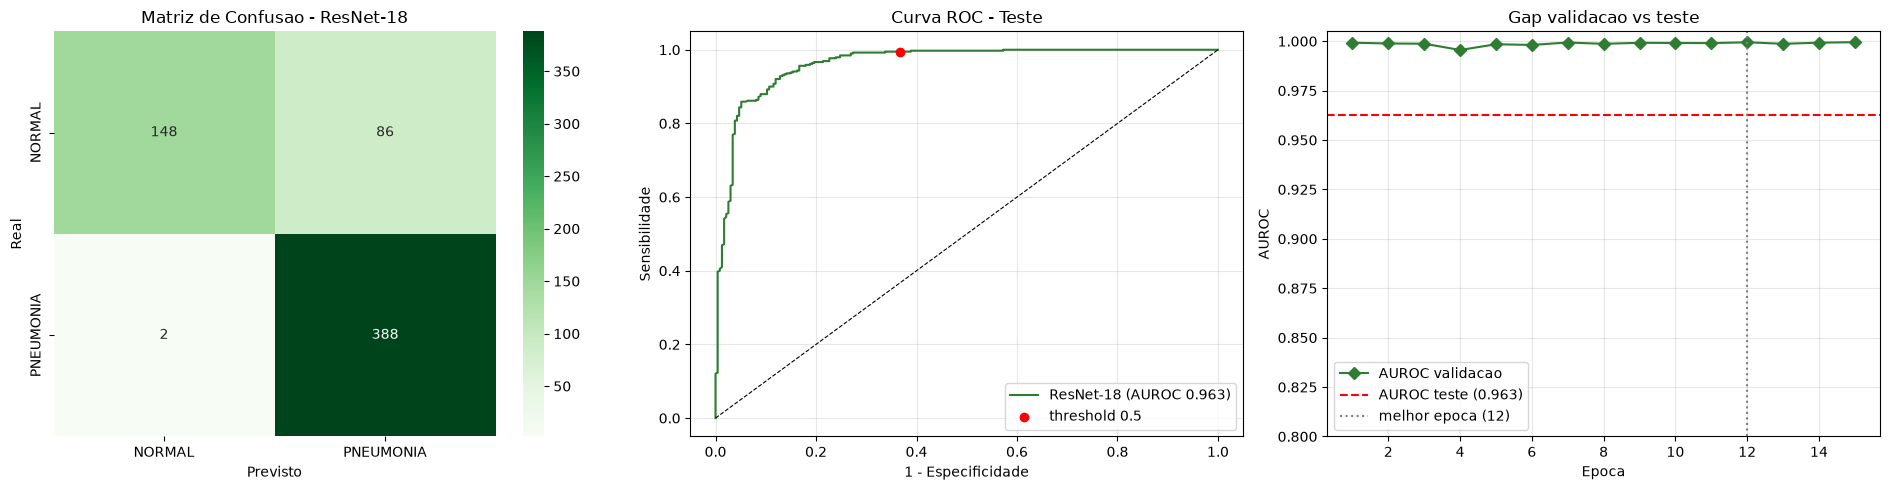


metricas salvas em runs/projeto2/resnet18_referencia_teto_20260828-001438/metricas_teste.json


In [6]:
# ---------------------------------------------------------------
# 6. Avaliacao no teste + a comparacao que motiva este notebook
# ---------------------------------------------------------------
ckpt = torch.load(CKPT_PATH)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"checkpoint da epoca {ckpt['epoca']} (val_auroc {ckpt['val_auroc']:.4f})\n")

probs, test_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        probs.extend(torch.softmax(outputs, 1)[:, 1].cpu().numpy())
        test_labels.extend(labels.numpy())
probs, test_labels = np.array(probs), np.array(test_labels)
preds = (probs >= 0.5).astype(int)

cm = confusion_matrix(test_labels, preds)
tn, fp, fn, tp = cm.ravel()
sens, spec = tp / (tp + fn), tn / (tn + fp)
acc = (tp + tn) / cm.sum()
auroc = roc_auc_score(test_labels, probs)
auprc = average_precision_score(test_labels, probs)
auroc_val = val_aurocs[best_epoch - 1]

print(classification_report(test_labels, preds, target_names=class_names, digits=3))
print(f"Acuracia            : {acc:.1%}")
print(f"Sensibilidade       : {sens:.1%}")
print(f"Especificidade      : {spec:.1%}")
print(f"Acuracia balanceada : {(sens+spec)/2:.1%}")
print(f"AUROC               : {auroc:.4f}")
print(f"AUPRC               : {auprc:.4f}")

print("\n" + "=" * 62)
print("A PERGUNTA QUE ESTE NOTEBOOK RESPONDE")
print("=" * 62)
print(f"AUROC validacao : {auroc_val:.4f}")
print(f"AUROC teste     : {auroc:.4f}")
print(f"delta           : {auroc_val - auroc:+.4f}")
print()
print("Referencia da CNN do zero (projeto2.ipynb):")
print("  cabeca flatten : AUROC teste 0,9290  delta +0,0694")
print("  cabeca gap     : AUROC teste 0,9424  delta +0,0540")
print()
if auroc_val - auroc > 0.02:
    print("-> O gap PERSISTE mesmo com pesos pre-treinados em 1,2 milhao de")
    print("   imagens. Isso CONFIRMA que parte do gap e deslocamento de")
    print("   distribuicao entre train/ e test/, irredutivel por arquitetura.")
else:
    print("-> O gap FECHOU. A causa era capacidade do model, e o diagnostico")
    print("   de deslocamento de distribuicao precisa ser revisto.")

print("\n" + "=" * 62)
print("varredura de threshold no TESTE (diagnostico)")
print(f"{'thr':>6} {'sens':>7} {'spec':>7} {'bal':>7}")
for t in (0.5, 0.7, 0.8, 0.9, 0.95, 0.99):
    p = (probs >= t).astype(int)
    _tn, _fp, _fn, _tp = confusion_matrix(test_labels, p, labels=[0, 1]).ravel()
    _se = _tp / (_tp + _fn) if (_tp + _fn) else 0.0
    _sp = _tn / (_tn + _fp) if (_tn + _fp) else 0.0
    print(f"{t:6.2f} {_se:7.1%} {_sp:7.1%} {(_se+_sp)/2:7.1%}")

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_xlabel('Previsto'); axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusao - ResNet-18')

fpr, tpr, _ = roc_curve(test_labels, probs)
axes[1].plot(fpr, tpr, color='#2E7D32', label=f'ResNet-18 (AUROC {auroc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=.8)
axes[1].scatter([1 - spec], [sens], c='red', zorder=5, label='threshold 0.5')
axes[1].set_xlabel('1 - Especificidade'); axes[1].set_ylabel('Sensibilidade')
axes[1].set_title('Curva ROC - Teste'); axes[1].legend(); axes[1].grid(alpha=.3)

ep = range(1, len(val_aurocs) + 1)
axes[2].plot(ep, val_aurocs, marker='D', color='#2E7D32', label='AUROC validacao')
axes[2].axhline(auroc, ls='--', color='red', label=f'AUROC teste ({auroc:.3f})')
axes[2].axvline(best_epoch, ls=':', color='gray', label=f'melhor epoca ({best_epoch})')
axes[2].set_xlabel('Epoca'); axes[2].set_ylabel('AUROC'); axes[2].set_ylim(0.8, 1.005)
axes[2].set_title('Gap validacao vs teste'); axes[2].legend(); axes[2].grid(alpha=.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "resnet18_avaliacao.png", dpi=130, bbox_inches='tight')
plt.show()

metrics = {"run": RUN_NAME, "checkpoint_epoca": int(ckpt["epoca"]),
            "matriz_confusao": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
            "accuracy": float(acc), "sensitivity": float(sens),
            "specificity": float(spec), "acuracia_balanceada": float((sens+spec)/2),
            "auroc": float(auroc), "auprc": float(auprc),
            "auroc_validacao": float(auroc_val),
            "delta_auroc_val_teste": float(auroc_val - auroc),
            "params_totais": int(n_total)}
with open(RUN_DIR / "metricas_teste.json", "w") as f:
    json.dump(metrics, f, indent=2)
writer.close()
print(f"\nmetricas salvas em {RUN_DIR / 'metricas_teste.json'}")


## Como interpretar o resultado

Preencha a tabela abaixo com o número que a célula 6 imprimir e leve-a para o
relatório, na seção *Referência de Teto*:

| modelo | params | AUROC val | AUROC teste | delta | acc | sens | spec |
|---|---|---|---|---|---|---|---|
| CNN do zero, cabeça `flatten` | 8.483.074 | 0,9984 | 0,9290 | +0,0694 | 80,0% | 99,2% | 47,9% |
| CNN do zero, cabeça `gap` | 93.954 | 0,9964 | 0,9424 | +0,0540 | 79,6% | 99,2% | 47,0% |
| **ResNet-18 pré-treinada** | 11.177.538 | *(preencher)* | *(preencher)* | *(preencher)* | | | |

### A conclusão a escrever

Se o delta da ResNet-18 ficar **acima de 0,02**, a leitura é:

> O gap entre validação e teste tem **duas componentes**. Uma é redutível por
> arquitetura — cai de +0,0694 (cabeça densa) para +0,0540 (pooling global) e
> continua caindo com pesos pré-treinados. A outra é **irredutível**: mesmo um
> modelo pré-treinado em 1,2 milhão de imagens mantém gap residual, o que
> confirma deslocamento de distribuição entre as pastas `train/` e `test/`
> oficiais do dataset — e não falha da metodologia de particionamento, já que a
> validação foi construída com estratificação e agrupamento por paciente
> verificados (0% de vazamento).

### Por que a ResNet-18 não é a entrega

O enunciado exige arquitetura **projetada** pelo aluno, com justificativa de
número de filtros, profundidade e padding conectada ao problema. Um modelo
pré-treinado carregado de `torchvision.models` não demonstra esse critério.
O papel dele aqui é ser **régua**: quantificar quanto do erro residual é
atacável por engenharia de arquitetura e quanto é limite do dado.